# 03 — TFT Forecaster
### Standard Temporal Fusion Transformer - Event-Based Breakdown Forecasting
> Run 00_Data_Preparation.ipynb first.
>
> **Model A:** Binary forecaster (breakdown coming within H=5 events? yes/no)
> **Model B:** Type forecaster (which breakdown type is coming?)


In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import f1_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
torch.manual_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {DEVICE}')


✅ Device: cpu


In [2]:
with open('prepared_forecasting.pkl','rb') as f: d = pickle.load(f)
with open('encoder_reason.pkl','rb') as f: encoder_reason = pickle.load(f)

X_train = torch.FloatTensor(d['X_fc_train_seq']).to(DEVICE)
X_test  = torch.FloatTensor(d['X_fc_test_seq']).to(DEVICE)
y_train_bin = torch.LongTensor(d['y_fc_train_bin_seq']).to(DEVICE)
y_test_bin  = torch.LongTensor(d['y_fc_test_bin_seq']).to(DEVICE)
y_train_type = torch.LongTensor(d['y_fc_train_type_seq']).to(DEVICE)
y_test_type  = torch.LongTensor(d['y_fc_test_type_seq']).to(DEVICE)

NUM_FEATURES      = d['num_features']
TIME_STEPS        = d['TIME_STEPS']
H                 = d['H']
NUM_REASON_CLASSES = d['num_reason_classes']

# CLASS WEIGHTS (binary)
cc_bin = np.bincount(d['y_fc_train_bin_seq'])
cw_bin = 1.0 / cc_bin
cw_bin = cw_bin / cw_bin.sum() * len(cw_bin)
weights_bin = torch.FloatTensor(cw_bin).to(DEVICE)

train_loader_bin = DataLoader(TensorDataset(X_train, y_train_bin), batch_size=32, shuffle=True)

print(f'✅ Data loaded.')
print(f'   Features: {NUM_FEATURES}, TIME_STEPS: {TIME_STEPS}, H: {H}')
print(f'   Binary class counts : {cc_bin}')
print(f'   Binary class weights: {cw_bin.round(3)}')
print(f'   Reason classes: {list(encoder_reason.classes_)}')


✅ Data loaded.
   Features: 67, TIME_STEPS: 5, H: 5
   Binary class counts : [1503  492]
   Binary class weights: [0.493 1.507]
   Reason classes: ['High foot pressure', 'High thread tension', 'No Breakdown', 'Sewing without thread']


---
## TFT Architecture


In [3]:
# ── FOCAL LOSS (Lin et al., 2017) ─────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.weight = weight
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        ce = F.cross_entropy(inputs, targets, weight=self.weight,
                             label_smoothing=self.label_smoothing, reduction='none')
        pt = torch.exp(-ce)
        focal = ((1 - pt) ** self.gamma) * ce
        return focal.mean()


class GRN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout=0.1):
        super().__init__()
        self.fc1        = nn.Linear(input_size, hidden_size)
        self.fc2        = nn.Linear(hidden_size, output_size)
        self.gate_fc    = nn.Linear(hidden_size, output_size)
        self.elu        = nn.ELU()
        self.sigmoid    = nn.Sigmoid()
        self.dropout    = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(output_size)
        self.residual   = nn.Linear(input_size, output_size) if input_size != output_size else nn.Identity()

    def forward(self, x):
        h    = self.elu(self.fc1(x))
        h    = self.dropout(h)
        gate = self.sigmoid(self.gate_fc(h))
        out  = gate * self.fc2(h)
        return self.layer_norm(out + self.residual(x))


class VariableSelectionNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, dropout=0.1):
        super().__init__()
        self.input_grn = GRN(input_size, hidden_size, hidden_size, dropout)
        self.selection = nn.Linear(hidden_size, input_size)

    def forward(self, x):
        h = self.input_grn(x)
        weights = torch.softmax(self.selection(h), dim=-1)
        self.var_weights = weights.detach().cpu()
        return h * weights.unsqueeze(-1).sum(dim=-1).unsqueeze(-1).expand_as(h) if len(h.shape) > 2 else h


class TFT_Forecaster(nn.Module):
    def __init__(self, num_features, time_steps, num_classes,
                 hidden_size=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.time_steps   = time_steps
        self.input_proj   = GRN(num_features, hidden_size, hidden_size, dropout)
        self.lstm_encoder = nn.LSTM(hidden_size, hidden_size, 2,
                                    batch_first=True, dropout=dropout)
        self.attention    = nn.MultiheadAttention(hidden_size, num_heads,
                                                   dropout=dropout, batch_first=True)
        self.attn_norm    = nn.LayerNorm(hidden_size)
        self.post_attn_grn = GRN(hidden_size, hidden_size, hidden_size, dropout)
        self.classifier   = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, num_classes)
        )

    def forward(self, x):
        proj_out = []
        for t in range(self.time_steps):
            proj_out.append(self.input_proj(x[:, t, :]))
        proj_seq = torch.stack(proj_out, dim=1)
        lstm_out, _ = self.lstm_encoder(proj_seq)
        attn_out, self.attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        attn_out = self.attn_norm(attn_out + lstm_out)
        out = self.post_attn_grn(attn_out[:, -1, :])
        return self.classifier(out)

print('✅ TFT Forecaster defined (hidden=64, heads=4, lstm_layers=2, dropout=0.3)')
print('   Loss: FocalLoss(gamma=2.0, label_smoothing=0.1)')


✅ TFT Forecaster defined (hidden=64, heads=4, lstm_layers=2, dropout=0.3)
   Loss: FocalLoss(gamma=2.0, label_smoothing=0.1)


---
## Model A - Binary Forecaster
> Predicts: will a breakdown happen within the next 5 events?


In [4]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'TFT Model A (Binary) parameters: {sum(p.numel() for p in model_a.parameters()):,}')


TFT Model A (Binary) parameters: 115,234


Training TFT Model A (Binary Forecaster)...
Epoch   1 | Train: 0.7023 | Val: 0.6941
Epoch   2 | Train: 0.6934 | Val: 0.6921
Epoch   3 | Train: 0.6926 | Val: 0.6922
Epoch   4 | Train: 0.6932 | Val: 0.6928
Epoch   5 | Train: 0.6903 | Val: 0.6928
Epoch   6 | Train: 0.6905 | Val: 0.6936
Epoch   7 | Train: 0.6858 | Val: 0.6928
Epoch   8 | Train: 0.6860 | Val: 0.6934
Epoch   9 | Train: 0.6817 | Val: 0.6917
Epoch  10 | Train: 0.6792 | Val: 0.6938
Epoch  11 | Train: 0.6803 | Val: 0.6965
Epoch  12 | Train: 0.6809 | Val: 0.6924
Epoch  13 | Train: 0.6762 | Val: 0.6980
Epoch  14 | Train: 0.6705 | Val: 0.6946
Epoch  15 | Train: 0.6722 | Val: 0.6976
Epoch  16 | Train: 0.6613 | Val: 0.6986
Epoch  17 | Train: 0.6662 | Val: 0.7024
Epoch  18 | Train: 0.6645 | Val: 0.7059
Epoch  19 | Train: 0.6562 | Val: 0.7066
Epoch  20 | Train: 0.6483 | Val: 0.7086
Epoch  21 | Train: 0.6489 | Val: 0.7090
Epoch  22 | Train: 0.6526 | Val: 0.7183
Epoch  23 | Train: 0.6410 | Val: 0.7218
Epoch  24 | Train: 0.6431 | Val: 0.7

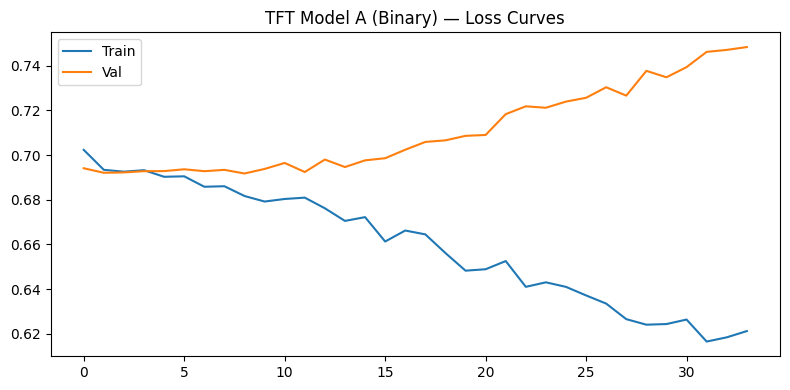

In [11]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)

EPOCHS = 150
optimizer = torch.optim.Adam(model_a.parameters(), lr=1e-4, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss(weight=weights_bin)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

best_val_loss = float('inf')
patience_counter = 0
PATIENCE = 25
train_losses, val_losses = [], []

print('Training TFT Model A (Binary Forecaster)...')
for epoch in range(EPOCHS):
    model_a.train()
    batch_losses = []
    for xb, yb in train_loader_bin:
        optimizer.zero_grad()
        loss = criterion(model_a(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_a.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())
    scheduler.step()

    model_a.eval()
    with torch.no_grad():
        val_loss = criterion(model_a(X_test), y_test_bin).item()
    train_loss = np.mean(batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model_a.state_dict(), 'best_tft_binary.pt')
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.title('TFT Model A (Binary) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_binary_loss.png', dpi=150); plt.show()

#### Evaluate Model A


TFT MODEL A — BINARY FORECASTER RESULTS (Test Set)
Accuracy : 71.72%
F1 Score : 0.6387
RMSE     : 0.5318
MAE      : 0.2828

                  precision    recall  f1-score   support

            Safe       0.75      0.94      0.83       373
Breakdown Coming       0.12      0.02      0.04       122

        accuracy                           0.72       495
       macro avg       0.44      0.48      0.44       495
    weighted avg       0.59      0.72      0.64       495



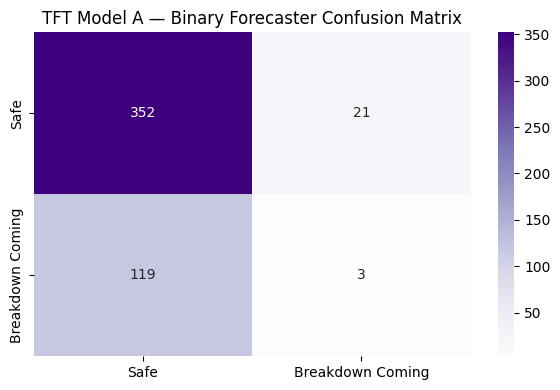

✅ Model A results saved.


In [6]:
model_a = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=2, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
model_a.load_state_dict(torch.load('best_tft_binary.pt'))
model_a.eval()
with torch.no_grad():
    y_pred_bin = np.argmax(torch.softmax(model_a(X_test), dim=1).cpu().numpy(), axis=1)
    y_true_bin = y_test_bin.cpu().numpy()

acc  = accuracy_score(y_true_bin, y_pred_bin)
f1   = f1_score(y_true_bin, y_pred_bin, average='weighted')
rmse = np.sqrt(mean_squared_error(y_true_bin, y_pred_bin))
mae  = mean_absolute_error(y_true_bin, y_pred_bin)

print('='*50)
print('TFT MODEL A — BINARY FORECASTER RESULTS (Test Set)')
print('='*50)
print(f'Accuracy : {acc*100:.2f}%')
print(f'F1 Score : {f1:.4f}')
print(f'RMSE     : {rmse:.4f}')
print(f'MAE      : {mae:.4f}')
print()
print(classification_report(y_true_bin, y_pred_bin, target_names=['Safe','Breakdown Coming']))

cm = confusion_matrix(y_true_bin, y_pred_bin)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Safe','Breakdown Coming'],
            yticklabels=['Safe','Breakdown Coming'])
plt.title('TFT Model A — Binary Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_binary_confusion.png', dpi=150); plt.show()

tft_binary_results = {'model':'TFT Forecaster','accuracy':acc,'f1':f1,'rmse':rmse,'mae':mae,
                       'cv_acc_mean':np.mean(accs),'cv_acc_std':np.std(accs),
                       'cv_f1_mean':np.mean(f1s),'cv_f1_std':np.std(f1s)}
with open('tft_binary_results.pkl','wb') as f: pickle.dump(tft_binary_results, f)
print('✅ Model A results saved.')


---
## Model B - Type Forecaster
> Trained only on records where future_breakdown = 1
>
> Predicts which breakdown type is coming


In [7]:
# Filter: only sequences where breakdown IS coming
mask_train = d['y_fc_train_bin_seq'] == 1
mask_test  = d['y_fc_test_bin_seq'] == 1

X_tr_type = torch.FloatTensor(d['X_fc_train_seq'][mask_train]).to(DEVICE)
X_te_type = torch.FloatTensor(d['X_fc_test_seq'][mask_test]).to(DEVICE)
y_tr_type = torch.LongTensor(d['y_fc_train_type_seq'][mask_train]).to(DEVICE)
y_te_type = torch.LongTensor(d['y_fc_test_type_seq'][mask_test]).to(DEVICE)

# Only keep classes that appear in the filtered data
# Re-encode to consecutive integers
from sklearn.preprocessing import LabelEncoder as LE
unique_types_train = np.unique(d['y_fc_train_type_seq'][mask_train])
print(f'✅ Type forecaster data ready.')
print(f'   Train: {X_tr_type.shape}  Test: {X_te_type.shape}')

# Class weights for type
if len(unique_types_train) > 1:
    cc_type = np.bincount(d['y_fc_train_type_seq'][mask_train])
    # Remove zero counts
    cc_type_nonzero = cc_type[cc_type > 0]
    cw_type = 1.0 / cc_type
    cw_type[cc_type == 0] = 0
    cw_type = cw_type / cw_type[cw_type > 0].sum() * (cc_type > 0).sum()
    weights_type = torch.FloatTensor(cw_type).to(DEVICE)
    print(f'   Type class counts : {cc_type}')

train_loader_type = DataLoader(TensorDataset(X_tr_type, y_tr_type), batch_size=32, shuffle=True)


✅ Type forecaster data ready.
   Train: torch.Size([492, 5, 67])  Test: torch.Size([122, 5, 67])
   Type class counts : [162 167   0 163]


TFT Model B (Type) parameters: 115,300
Training TFT Model B (Type Forecaster)...
Epoch   1 | Train: 0.7156 | Val: 0.6512
Epoch   2 | Train: 0.6249 | Val: 0.6056
Epoch   3 | Train: 0.5813 | Val: 0.5716
Epoch   4 | Train: 0.5706 | Val: 0.5493
Epoch   5 | Train: 0.5387 | Val: 0.5341
Epoch   6 | Train: 0.5395 | Val: 0.5266
Epoch   7 | Train: 0.5382 | Val: 0.5173
Epoch   8 | Train: 0.5166 | Val: 0.5089
Epoch   9 | Train: 0.5148 | Val: 0.5063
Epoch  10 | Train: 0.5101 | Val: 0.5008
Epoch  11 | Train: 0.5220 | Val: 0.5021
Epoch  12 | Train: 0.4990 | Val: 0.5051
Epoch  13 | Train: 0.4952 | Val: 0.4986
Epoch  14 | Train: 0.4997 | Val: 0.5003
Epoch  15 | Train: 0.4998 | Val: 0.4969
Epoch  16 | Train: 0.4895 | Val: 0.4952
Epoch  17 | Train: 0.4845 | Val: 0.4910
Epoch  18 | Train: 0.4720 | Val: 0.4905
Epoch  19 | Train: 0.4847 | Val: 0.4883
Epoch  20 | Train: 0.4814 | Val: 0.4878
Epoch  21 | Train: 0.4684 | Val: 0.4880
Epoch  22 | Train: 0.4827 | Val: 0.4865
Epoch  23 | Train: 0.4715 | Val: 0.4870

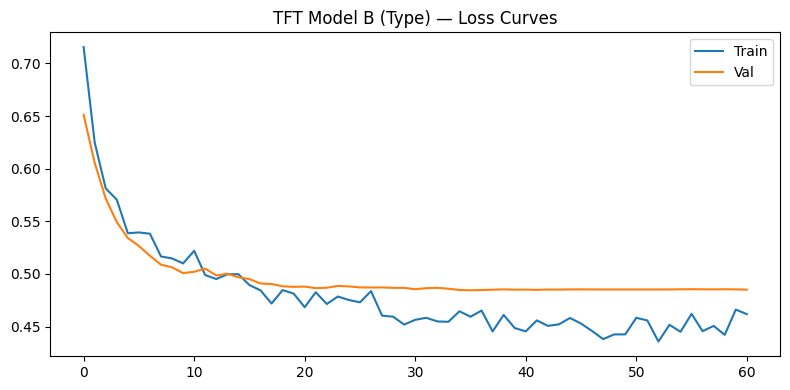

In [8]:
model_b = TFT_Forecaster(
    num_features=NUM_FEATURES, time_steps=TIME_STEPS,
    num_classes=NUM_REASON_CLASSES, hidden_size=64, num_heads=4, dropout=0.3
).to(DEVICE)
print(f'TFT Model B (Type) parameters: {sum(p.numel() for p in model_b.parameters()):,}')

EPOCHS    = 150
optimizer_b = torch.optim.AdamW(model_b.parameters(), lr=1e-4, weight_decay=1e-2)
criterion_b = FocalLoss(weight=weights_type, gamma=2.0, label_smoothing=0.1)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=50)

best_val_loss_b  = float('inf')
patience_b       = 0
train_losses_b, val_losses_b = [], []

print('Training TFT Model B (Type Forecaster)...')
for epoch in range(EPOCHS):
    model_b.train()
    batch_losses = []
    for xb, yb in train_loader_type:
        optimizer_b.zero_grad()
        loss = criterion_b(model_b(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_b.parameters(), 1.0)
        optimizer_b.step()
        batch_losses.append(loss.item())
    scheduler_b.step()

    model_b.eval()
    with torch.no_grad():
        val_loss = criterion_b(model_b(X_te_type), y_te_type).item()
    train_loss = np.mean(batch_losses)
    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    if val_loss < best_val_loss_b:
        best_val_loss_b = val_loss
        torch.save(model_b.state_dict(), 'best_tft_type.pt')
        patience_b = 0
    else:
        patience_b += 1
        if patience_b >= 25:
            print(f'Early stopping at epoch {epoch+1}')
            break

    print(f'Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

plt.figure(figsize=(8,4))
plt.plot(train_losses_b, label='Train')
plt.plot(val_losses_b, label='Val')
plt.title('TFT Model B (Type) — Loss Curves')
plt.legend(); plt.tight_layout()
plt.savefig('tft_type_loss.png', dpi=150); plt.show()


#### Evaluate Model B


TFT MODEL B — TYPE FORECASTER RESULTS
Accuracy : 31.15%
F1 Score : 0.3244

                       precision    recall  f1-score   support

   High foot pressure       0.17      0.32      0.23        28
  High thread tension       0.38      0.30      0.34        43
Sewing without thread       0.44      0.31      0.37        51

             accuracy                           0.31       122
            macro avg       0.33      0.31      0.31       122
         weighted avg       0.36      0.31      0.32       122



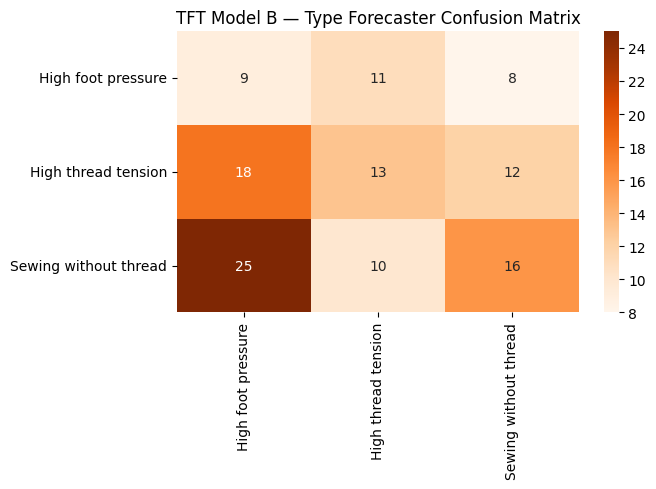

In [9]:
model_b.load_state_dict(torch.load('best_tft_type.pt'))
model_b.eval()
with torch.no_grad():
    y_pred_type = np.argmax(torch.softmax(model_b(X_te_type), dim=1).cpu().numpy(), axis=1)
    y_true_type = y_te_type.cpu().numpy()

# Get only classes that appear in test data (excludes 'No Breakdown')
unique_labels = sorted(set(y_true_type) | set(y_pred_type))
label_names = [encoder_reason.classes_[i] for i in unique_labels]

print('='*50)
print('TFT MODEL B — TYPE FORECASTER RESULTS')
print('='*50)
print(f'Accuracy : {accuracy_score(y_true_type, y_pred_type)*100:.2f}%')
print(f'F1 Score : {f1_score(y_true_type, y_pred_type, average="weighted"):.4f}')
print()
print(classification_report(y_true_type, y_pred_type, labels=unique_labels, target_names=label_names))

cm = confusion_matrix(y_true_type, y_pred_type, labels=unique_labels)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_names, yticklabels=label_names)
plt.title('TFT Model B — Type Forecaster Confusion Matrix')
plt.tight_layout()
plt.savefig('tft_type_confusion.png', dpi=150); plt.show()

#### Save Artifacts


In [10]:
tft_forecast_config = {
    'num_features'       : NUM_FEATURES,
    'time_steps'         : TIME_STEPS,
    'H'                  : H,
    'num_classes_binary'  : 2,
    'num_classes_type'    : NUM_REASON_CLASSES,
    'hidden_size'         : 64,
    'num_heads'           : 4,
}
with open('tft_forecast_config.pkl','wb') as f: pickle.dump(tft_forecast_config, f)

print('✅ Saved:')
print('   best_tft_binary.pt        — Binary forecaster weights (best CV fold)')
print('   best_tft_type.pt          — Type forecaster weights')
print('   tft_forecast_config.pkl   — Model config (hidden=64, heads=4)')
print('   tft_binary_results.pkl    — Binary evaluation metrics + CV results')


✅ Saved:
   best_tft_binary.pt        — Binary forecaster weights (best CV fold)
   best_tft_type.pt          — Type forecaster weights
   tft_forecast_config.pkl   — Model config (hidden=64, heads=4)
   tft_binary_results.pkl    — Binary evaluation metrics + CV results
